# Data Drift Analysis over Years – Utrecht NO₂ Project

This notebook analyses **data drift over time** for the Utrecht air quality dataset.

We will:
- 1. Load and join raw weather + air-quality data
- 2. Add a `year` column and drop not used features.
- 3. Compute yearly summary statistics
- 4. Visualize changes in distributions per year
- 5. Run simple drift tests (KS test, PSI) per feature vs a baseline year


In [1]:
import yaml
import os
from pathlib import Path
import pandas as pd
import os
from typing import List

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

os.chdir(Path.cwd().parent)
from src.data.api_requests import fetch_weather_data, fetch_air_quality_data

### 1. Load and join raw weather + air-quality data

In [3]:
# download raw data based on config
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)
    
    
# fetch_weather_data(cfg)
# fetch_air_quality_data(cfg)

In [4]:
MONITOR_COLS = [
    "nitrogen_dioxide",
    "pm10",
    "pm2_5",
    "ozone",
    "carbon_monoxide",
    "sulphur_dioxide",
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "precipitation",
    "pressure_msl",
    "cloud_cover_high",
    "wind_speed_10m",
    "wind_gusts_10m",
]

loc = list(cfg["api_requests"]["locations"].keys())[0]
start_date = cfg["api_requests"]["time"]["start_date"]
end_date = cfg["api_requests"]["time"]["end_date"]
# Load joined or per-source data
aq = pd.read_csv(f"data/raw/air_quality/{loc}_air_quality_{start_date}_to_{end_date}.csv", parse_dates=["time"])
wx = pd.read_csv(f"data/raw/weather/{loc}_weather_{start_date}_to_{end_date}.csv", parse_dates=["time"])

df = pd.merge(wx, aq, on=["time", "location"], how="inner")
assert len(df) == len(wx) == len(aq), "Rows were dropped during merge!"

### 2. Add a `year` column and drop not used features

In [5]:
cols_to_drop = [
    "apparent_temperature",
    "rain",
    "snowfall",
    "snow_depth",
    "weather_code",
    "surface_pressure",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "wind_speed_100m",
    "wind_direction_100m",
    "soil_temperature_0_to_7cm",
    "soil_temperature_7_to_28cm",
    "soil_temperature_28_to_100cm",
    "soil_temperature_100_to_255cm",
    "soil_moisture_0_to_7cm",
    "soil_moisture_7_to_28cm",
    "soil_moisture_28_to_100cm",
    "soil_moisture_100_to_255cm",
    "carbon_dioxide",
    "methane",
    "uv_index_clear_sky",
    "uv_index",
    "aerosol_optical_depth",
    "ammonia",
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df["year"] = df["time"].dt.year

df["year"].value_counts().sort_index()


year
2016    8760
2017    8760
2018    8760
2019    8760
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
Name: count, dtype: int64

### 3. Compute yearly summary statistics

In [6]:
yearly_stats = df.groupby("year")[MONITOR_COLS].agg(["mean", "std", "min", "max"])
yearly_stats

nitrogen_dioxide                             pm10                         \
                 mean        std  min   max       mean        std  min    max   
year                                                                            
2016        21.249110  13.442984  1.9  75.2  18.149897   9.549895  1.3   80.1   
2017        21.400890  12.671612  2.7  74.7  18.210388  10.672881  2.3  143.6   
2018        18.592854  11.388924  1.7  72.5  17.592511   9.525176  1.9   94.4   
2019        19.440205  11.958551  2.4  75.6  15.995902   9.164079  2.6   93.4   
2020        15.224636   9.522892  1.4  64.6  14.952209   7.744838  2.0   80.7   
2021        14.897409   9.764918  2.0  59.1  16.651164   8.201729  3.1  112.6   
2022        17.334669  10.987625  2.3  73.4  16.033813   7.681176  2.9   59.0   
2023        14.929018   9.497666  2.6  65.8  15.190479   6.593443  3.9   59.6   
2024        16.559347  11.776946  1.9  75.5  14.518272   7.453116  1.5   51.6   

          pm2_5            ... cloud_cover_high      wind_speed_10m            \
           mean       std  ...              min  max           mean       std   
year                       ...                                                  
2016  11.807591  8.443657  ...                0  100      14.007043  6.832860   
2017  11.676804  9.815381  ...                0  100      14.236792  7.033280   
2018  11.040753  8.572081  ...                0  100      14.323139  6.739311   
2019  10.291107  7.864623  ...                0  100      14.739521  7.092119   
2020   9.139674  6.378764  ...                0  100      15.550615  7.964064   
2021  10.359989  6.482480  ...                0  100      13.875217  6.859733   
2022  10.096267  6.212141  ...                0  100      14.162945  7.279007   
2023   9.041929  5.279061  ...                0  100      15.694247  7.515202   
2024  10.700877  6.664817  ...                0  100      14.493568  7.019220   

                wind_gusts_10m                         
      min   max           mean        std  min    max  
year                                                   
2016  0.5  49.3      27.115445  13.124995  2.5   93.2  
2017  0.0  49.5      28.095856  13.541353  1.8  105.5  
2018  0.7  65.6      28.239030  13.030388  2.5  128.9  
2019  0.5  46.8      29.102763  13.929530  2.9  101.9  
2020  0.5  55.0      30.628825  15.369405  1.8  115.2  
2021  0.0  55.4      27.215514  13.381626  1.8  113.8  
2022  0.5  55.2      27.100114  13.462172  2.2   98.6  
2023  0.7  49.2      29.804829  13.896937  2.2   89.6  
2024  0.0  46.6      28.133117  13.267409  1.8   90.4  

[9 rows x 56 columns]

### 4. Visualize changes in distributions per year

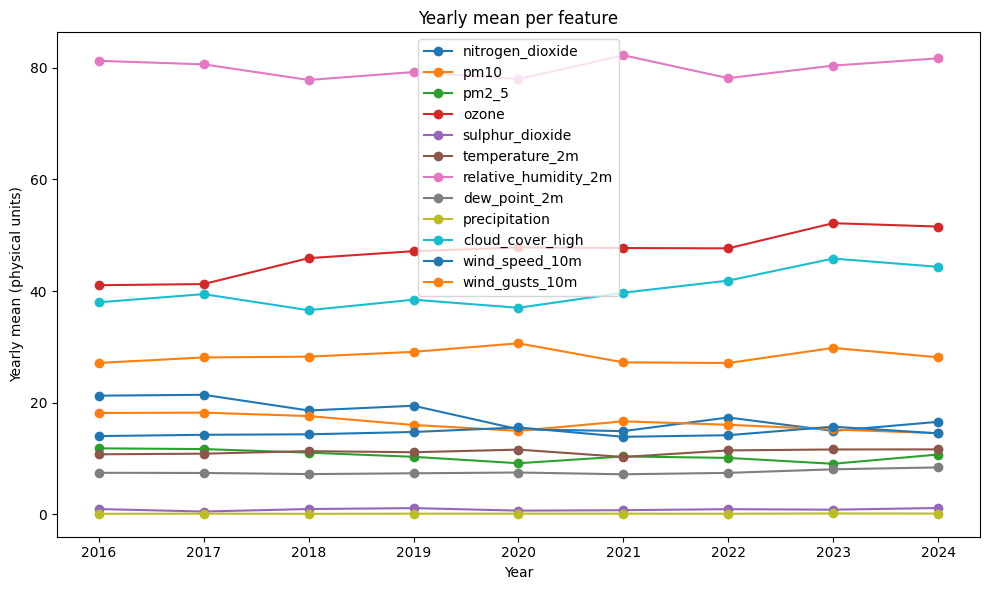

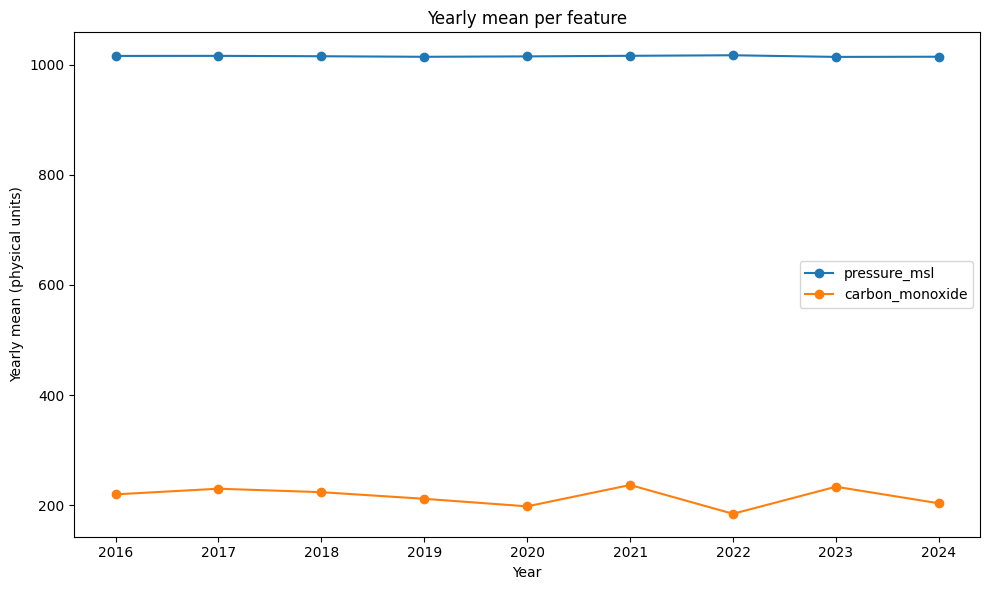

In [18]:
from pyparsing import col


def plot_yearly_means(df: pd.DataFrame, features: List[str]) -> None:
    yearly_mean = df.groupby("year")[features].mean()

    plt.figure(figsize=(10, 6))
    for col in features:
        plt.plot(yearly_mean.index, yearly_mean[col], marker="o", label=col)
    plt.xlabel("Year")
    plt.ylabel("Yearly mean (physical units)")
    plt.title("Yearly mean per feature")
    plt.legend()
    plt.tight_layout()
    plt.show()


columns = MONITOR_COLS.copy()
columns.remove("pressure_msl")
columns.remove("carbon_monoxide")
plot_yearly_means(df, columns)
plot_yearly_means(df, ["pressure_msl", "carbon_monoxide"])


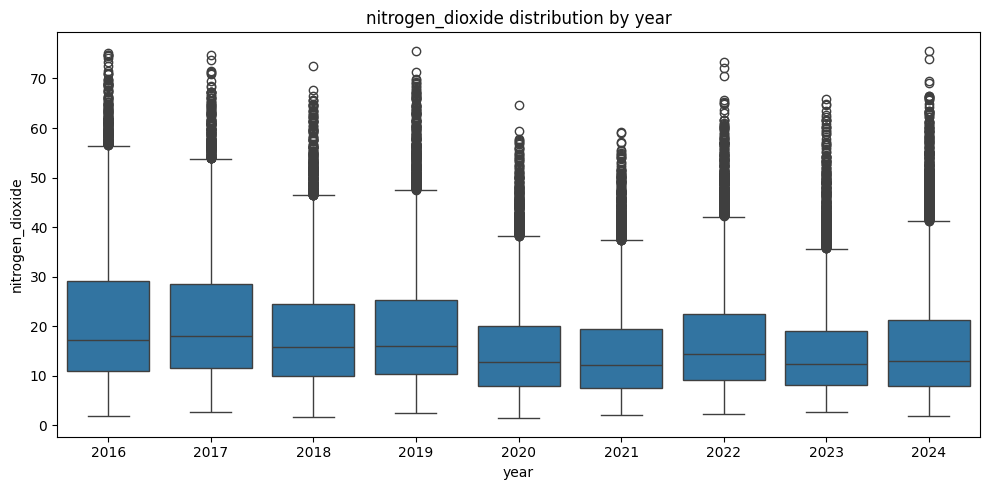

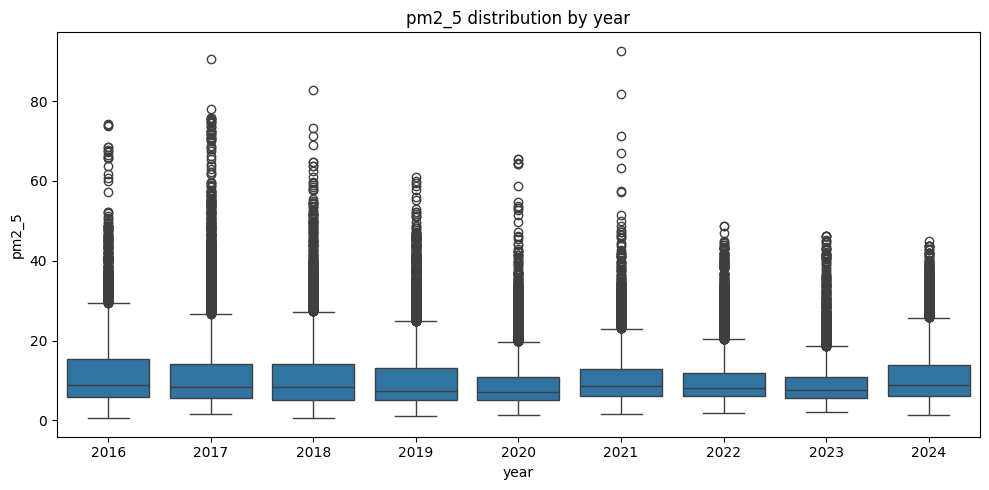

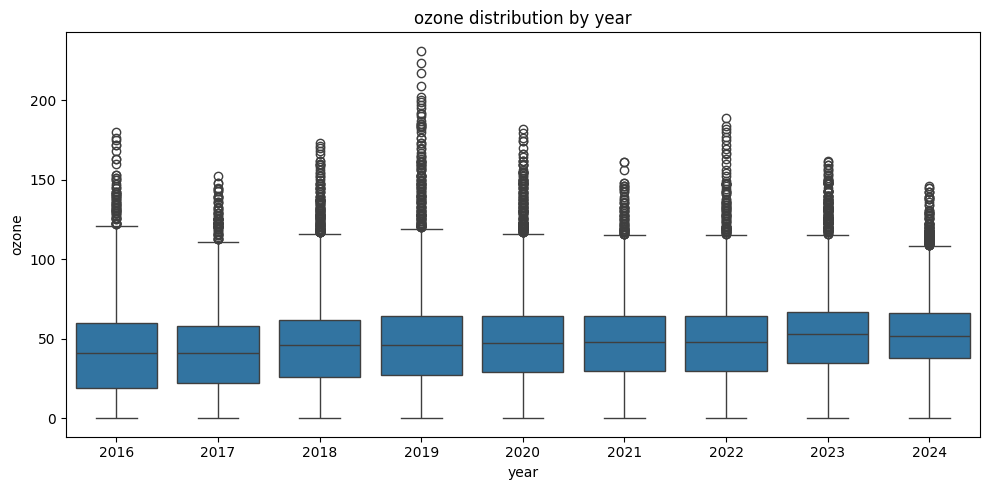

In [19]:
def boxplot_feature_by_year(df: pd.DataFrame, feature: str) -> None:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="year", y=feature)
    plt.title(f"{feature} distribution by year")
    plt.tight_layout()
    plt.show()


for col in ["nitrogen_dioxide", "pm2_5", "ozone"]:
    boxplot_feature_by_year(df, col)

### 5. Run simple drift tests (KS test, PSI) per feature vs a baseline year

In [21]:
def ks_drift_vs_baseline(
    df: pd.DataFrame,
    baseline_year: int,
    cols: List[str],
) -> pd.DataFrame:
    """
    Compute KS statistics and p-values comparing each year to a baseline year
    for the given numeric columns.
    """
    results = []
    base = df[df["year"] == baseline_year]

    for year, df_y in df.groupby("year"):
        if year == baseline_year:
            continue
        for col in cols:
            x = base[col].dropna().values
            y = df_y[col].dropna().values
            if len(x) == 0 or len(y) == 0:
                continue
            stat, pval = ks_2samp(x, y)
            results.append(
                {
                    "feature": col,
                    "baseline_year": baseline_year,
                    "compare_year": year,
                    "ks_stat": stat,
                    "p_value": pval,
                }
            )

    return pd.DataFrame(results).sort_values(["feature", "compare_year"])


baseline_year = int(df["year"].min())
ks_results = ks_drift_vs_baseline(df, baseline_year, MONITOR_COLS)
print(ks_results)


             feature  baseline_year  compare_year   ks_stat        p_value
4    carbon_monoxide           2016          2017  0.094178   3.232681e-34
18   carbon_monoxide           2016          2018  0.047374   5.753380e-09
32   carbon_monoxide           2016          2019  0.062329   3.255331e-15
46   carbon_monoxide           2016          2020  0.144167   6.145908e-80
60   carbon_monoxide           2016          2021  0.166210  5.220540e-106
..               ...            ...           ...       ...            ...
54    wind_speed_10m           2016          2020  0.090934   5.236670e-32
68    wind_speed_10m           2016          2021  0.013699   3.837046e-01
82    wind_speed_10m           2016          2022  0.019863   6.309722e-02
96    wind_speed_10m           2016          2023  0.107306   2.587340e-44
110   wind_speed_10m           2016          2024  0.060383   2.386426e-14

[112 rows x 5 columns]


In [ ]:
def compute_psi(
    expected: np.ndarray,
    actual: np.ndarray,
    n_bins: int = 10,
) -> float:
    """
    Compute Population Stability Index between two 1D arrays.

    expected: baseline distribution
    actual:   comparison distribution
    """
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    if len(expected) == 0 or len(actual) == 0:
        return np.nan

    quantiles = np.linspace(0, 1, n_bins + 1)
    cuts = expected.quantile(quantiles).values
    cuts[0] = -np.inf
    cuts[-1] = np.inf

    expected_counts, _ = np.histogram(expected, bins=cuts)
    actual_counts, _ = np.histogram(actual, bins=cuts)

    expected_pct = expected_counts / expected_counts.sum()
    actual_pct = actual_counts / actual_counts.sum()

    mask = (expected_pct > 0) & (actual_pct > 0)

    psi = np.sum(
        (actual_pct[mask] - expected_pct[mask])
        * np.log(actual_pct[mask] / expected_pct[mask])
    )
    return psi


def psi_drift_vs_baseline(
    df: pd.DataFrame,
    baseline_year: int,
    cols: List[str],
    n_bins: int = 10,
) -> pd.DataFrame:
    results = []
    base = df[df["year"] == baseline_year]

    for year, df_y in df.groupby("year"):
        if year == baseline_year:
            continue
        for col in cols:
            psi = compute_psi(
                base[col].values,
                df_y[col].values,
                n_bins=n_bins,
            )
            results.append(
                {
                    "feature": col,
                    "baseline_year": baseline_year,
                    "compare_year": year,
                    "psi": psi,
                }
            )

    return pd.DataFrame(results).sort_values(["feature", "compare_year"])


psi_results = psi_drift_vs_baseline(df, baseline_year, MONITOR_COLS, n_bins=10)
psi_results.head(20)


,feature,baseline_year,compare_year,psi
4,carbon_monoxide,2016,2017,0.134608
18,carbon_monoxide,2016,2018,0.019138
32,carbon_monoxide,2016,2019,0.025432
46,carbon_monoxide,2016,2020,0.128938
60,carbon_monoxide,2016,2021,0.210844
74,carbon_monoxide,2016,2022,0.391958
88,carbon_monoxide,2016,2023,0.101036
102,carbon_monoxide,2016,2024,0.093457
11,cloud_cover_high,2016,2017,0.012485
25,cloud_cover_high,2016,2018,0.017963


### Drift Overview Table (2016 → 2024)

| Feature                       | Drift Level         | PSI Range         | KS Range         | Interpretation                                                                   |
| ----------------------------- | ------------------- | ----------------- | ---------------- | -------------------------------------------------------------------------------- |
| **Sulphur dioxide**           | **Very High**       | 0.07 → **1.02**   | 0.05 → **0.36+** | Strong regime/measurement change; unstable across entire period                  |
| **Nitrogen dioxide (target)** | **High**            | 0.02 → **0.32**   | 0.04 → **0.21**  | Clear distribution shift (traffic, policy, COVID effect); target concept changes |
| **Carbon monoxide**           | **Moderate → High** | 0.02 → **0.39**   | 0.05 → **0.24**  | Significant drift especially 2020–2022                                           |
| **Ozone**                     | **Moderate → High** | 0.03 → **0.29**   | 0.05 → **0.21**  | Climatic/seasonal trend changes over years                                       |
| **PM10**                      | **Moderate**        | 0.01 → **0.19**   | 0.05 → **0.17**  | Increasing drift from 2019 onward                                                |
| **PM2.5**                     | **Moderate**        | 0.01 → **0.23**   | 0.04 → **0.16**  | Stronger drift in 2020–2023                                                      |
| **Cloud_cover_high**          | **Moderate**        | 0.01 → **0.25**   | 0.02 → **0.19**  | Drift grows after 2021, likely climatological                                    |
| **Dew_point_2m**              | **Low → Moderate**  | 0.01 → **0.11**   | 0.02 → **0.12**  | Slight climatic drift; manageable                                                |
| **Temperature_2m**            | **Low → Moderate**  | 0.02 → **0.08**   | 0.04 → **0.10**  | Mild climatic drift; stable for modeling                                         |
| **Relative_humidity_2m**      | **Low → Moderate**  | 0.004 → **0.066** | 0.02 → **0.09**  | Slight drift but stable enough                                                   |
| **Pressure_msl**              | **Low → Moderate**  | 0.009 → **0.074** | 0.02 → **0.10**  | Climatic but stable                                                              |
| **Wind_speed_10m**            | **Low**             | 0.001 → **0.06**  | 0.01 → **0.09**  | Very stable                                                                      |
| **Wind_gusts_10m**            | **Low**             | 0.002 → **0.06**  | 0.01 → **0.10**  | Very stable                                                                      |
| **Precipitation**             | **Very Low**        | 0.000 → 0.012     | 0.02 → 0.09      | Essentially no drift                                                             |

The drift analysis shows that meteorological drivers such as temperature, humidity, pressure, and wind variables remain largely stable across 2016–2024, exhibiting only mild distributional changes. In contrast, several pollutant-related features—including NO₂ (the target variable), SO₂, CO, O₃, PM10, and PM2.5—show substantial drift, particularly around 2020–2023. This likely reflects real-world changes such as emission regulations, COVID-related traffic reductions, or shifts in atmospheric conditions. Features such as sulphur dioxide and ozone demonstrate the strongest drift and may encode structural changes in the underlying processes rather than simple noise.


### Strategies to mitigate this

1. **Weight recent data more heavily during training:**
   Helps the model adapt to current environmental conditions instead of being dominated by outdated historical patterns.

2. **Pretrain on past years and fine-tune on the most recent data:**
   Captures long-term structure while aligning the final model with the latest distribution; evaluate on a rolling basis (e.g., 2026) to monitor ongoing drift.

3. **Use per-year SHAP analysis:**
   Reveals how feature importance changes over time and helps detect concept drift that may degrade model performance.


In [22]:
from IPython.display import display, HTML

def scrollable_df(df, height=300):
    display(HTML(df.to_html()\
                 .replace('table', f'table style="display:block;max-height:{height}px;overflow-y:scroll;"')))

# Usage
scrollable_df(psi_results, height=500)
scrollable_df(ks_results, height=500)


,feature,baseline_year,compare_year,psi
4,carbon_monoxide,2016,2017,0.134608
18,carbon_monoxide,2016,2018,0.019138
32,carbon_monoxide,2016,2019,0.025432
46,carbon_monoxide,2016,2020,0.128938
60,carbon_monoxide,2016,2021,0.210844
74,carbon_monoxide,2016,2022,0.391958
88,carbon_monoxide,2016,2023,0.101036
102,carbon_monoxide,2016,2024,0.093457
11,cloud_cover_high,2016,2017,0.012485
25,cloud_cover_high,2016,2018,0.017963


,feature,baseline_year,compare_year,ks_stat,p_value
4,carbon_monoxide,2016,2017,0.094178,3.232681e-34
18,carbon_monoxide,2016,2018,0.047374,5.753380e-09
32,carbon_monoxide,2016,2019,0.062329,3.255331e-15
46,carbon_monoxide,2016,2020,0.144167,6.145908e-80
60,carbon_monoxide,2016,2021,0.166210,5.220540e-106
74,carbon_monoxide,2016,2022,0.239155,3.944149e-220
88,carbon_monoxide,2016,2023,0.133904,7.677245e-69
102,carbon_monoxide,2016,2024,0.120150,1.332097e-55
11,cloud_cover_high,2016,2017,0.025228,7.577418e-03
25,cloud_cover_high,2016,2018,0.055023,5.997132e-12
